# Experiment: Nitrogen Shipping Failure Model Exploration

Objective:
- Confirm the fixed-volume thresholds that separate no-vent, venting, and return-leg underpressure behavior.
- Reproduce a minimal set of summary tables and plots using the existing project model instead of duplicating the model logic in the notebook.

Success criteria:
- Import `projects/shipping/nitrogen_shipping_failure_model.py` directly from the repo.
- Recompute the default analytic thresholds and compare a 40 L and 60 L rigid-volume case.
- Sweep rigid system volume and identify where the worst-case gauge pressure crosses zero.


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repo root from the current working directory.")


REPO_ROOT = find_repo_root()
PROJECT_DIR = REPO_ROOT / "projects" / "shipping"
MODEL_PATH = PROJECT_DIR / "nitrogen_shipping_failure_model.py"
GENERATED_DIR = Path("D:/matlab-mcp/docs/shipping/generated")

spec = importlib.util.spec_from_file_location("shipping_model", MODEL_PATH)
shipping_model = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(shipping_model)

{
    "repo_root": str(REPO_ROOT),
    "project_dir": str(PROJECT_DIR),
    "model_path": str(MODEL_PATH),
    "generated_dir_exists": GENERATED_DIR.exists(),
}


{'repo_root': 'D:\\Quarto',
 'project_dir': 'D:\\Quarto\\projects\\shipping',
 'model_path': 'D:\\Quarto\\projects\\shipping\\nitrogen_shipping_failure_model.py',
 'generated_dir_exists': True}

## Plan

- Hypothesis: once the rigid system volume is large enough to force outbound venting, irreversible nitrogen mass loss can drive the return leg sub-atmospheric.
- Variables to sweep: rigid fixed volume under the default bag geometry, plus an optional comparison to a `2 psig` vent threshold.
- Metrics to record: analytic thresholds, minimum internal-minus-ambient pressure, state at the minimum, and total vented nitrogen mass.


In [8]:
PSIG_TO_BAR = 0.0689475729

DEFAULTS = {
    "v_bag_init_L": 11.0,
    "v_bag_max_L": 22.0,
    "p_initial_gauge_bar": 0.0,
    "p_vent_gauge_bar": 0.0,
}


def summarize_case(v_fixed_L: float, **kwargs):
    result = shipping_model.simulate_case(v_fixed_L=v_fixed_L, **kwargs)
    idx_min = int(np.argmin(result["dp_bar"]))
    summary = {
        "v_fixed_L": float(v_fixed_L),
        "min_dp_bar": float(result["dp_bar"][idx_min]),
        "time_at_min_hr": float(result["t_hr"][idx_min]),
        "bag_volume_at_min_L": float(result["v_bag_L"][idx_min]),
        "state_at_min": str(result["state"][idx_min]),
        "total_vented_kg": float(np.sum(result["vented_mass_kg_step"])),
        "went_negative": bool(np.min(result["dp_bar"]) < 0.0),
    }
    return result, summary


no_vent_limit_L = shipping_model.analytic_threshold_no_vent(
    v_bag_init_L=DEFAULTS["v_bag_init_L"],
    v_bag_max_L=DEFAULTS["v_bag_max_L"],
    p_seal_bar_abs=1.01325 + DEFAULTS["p_initial_gauge_bar"],
    p_low_bar_abs=0.753 * 1.01325,
    T_seal_C=20.0,
    T_hot_C=40.0,
)

return_limit_ideal_L = shipping_model.analytic_threshold_negative_return(
    v_bag_max_L=DEFAULTS["v_bag_max_L"],
    p_peak_bar_abs=0.753 * 1.01325 + DEFAULTS["p_vent_gauge_bar"],
    p_return_bar_abs=1.01325,
    T_peak_C=40.0,
    T_return_C=20.0,
    min_required_gauge_bar=0.0,
)

return_limit_2psig_L = shipping_model.analytic_threshold_negative_return(
    v_bag_max_L=DEFAULTS["v_bag_max_L"],
    p_peak_bar_abs=0.753 * 1.01325 + 2.0 * PSIG_TO_BAR,
    p_return_bar_abs=1.01325,
    T_peak_C=40.0,
    T_return_C=20.0,
    min_required_gauge_bar=0.0,
)

threshold_df = pd.DataFrame(
    [
        {
            "metric": "No-vent threshold (ideal vent assumptions)",
            "value_L": no_vent_limit_L,
            "notes": "Largest rigid volume that avoids any outbound venting.",
        },
        {
            "metric": "Return nonnegative threshold (ideal vent)",
            "value_L": return_limit_ideal_L,
            "notes": "Above this rigid volume, the return leg goes sub-atmospheric after venting.",
        },
        {
            "metric": "Return nonnegative threshold (2 psig vent)",
            "value_L": return_limit_2psig_L,
            "notes": "Higher vent threshold raises retained peak pressure and shifts the return threshold upward.",
        },
    ]
)
threshold_df["value_L"] = threshold_df["value_L"].round(2)
threshold_df


,metric,value_L,notes
0,No-vent threshold (ideal vent assumptions),15.28,Largest rigid volume that avoids any outbound ...
1,Return nonnegative threshold (ideal vent),52.55,"Above this rigid volume, the return leg goes s..."
2,Return nonnegative threshold (2 psig vent),109.19,Higher vent threshold raises retained peak pre...


## Minimal Baseline

- Use a `40 L` case as a venting-but-still-nonnegative example.
- Use a `60 L` case as a return-leg underpressure example.
- Keep the bag settings at the defaults from the project script so the notebook stays aligned with the current note.


In [9]:
case_results = {}
case_summaries = []

for v_fixed_L in (40.0, 60.0):
    result, summary = summarize_case(v_fixed_L=v_fixed_L, **DEFAULTS)
    case_results[f"{v_fixed_L:.0f} L"] = result
    case_summaries.append(summary)

baseline_df = pd.DataFrame(case_summaries).round(
    {
        "v_fixed_L": 1,
        "min_dp_bar": 4,
        "time_at_min_hr": 2,
        "bag_volume_at_min_L": 2,
        "total_vented_kg": 6,
    }
)
baseline_df


,v_fixed_L,min_dp_bar,time_at_min_hr,bag_volume_at_min_L,state_at_min,total_vented_kg,went_negative
0,40.0,0.0000,0.0,11.0,tracking ambient,0.008496,False
1,60.0,-0.0371,24.0,0.0,bag collapsed,0.015369,True


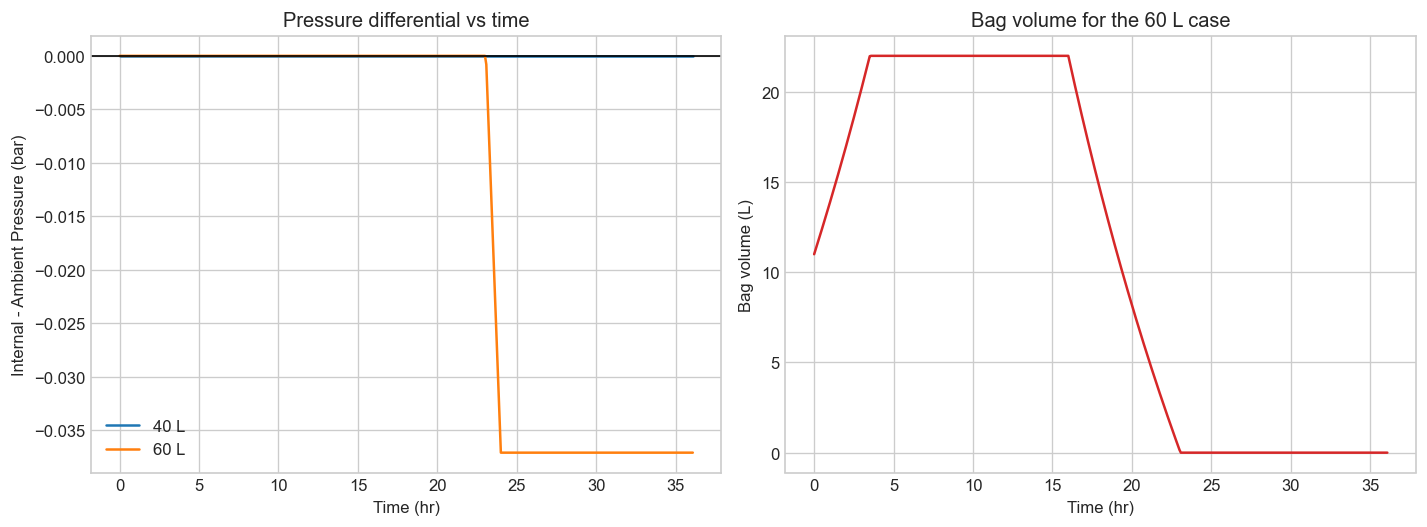

In [14]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4.5))

for label, result in case_results.items():
    axes[0].plot(result["t_hr"], result["dp_bar"], label=label)

axes[0].axhline(0.0, color="black", linewidth=1.0)
axes[0].set_title("Pressure differential vs time")
axes[0].set_xlabel("Time (hr)")
axes[0].set_ylabel("Internal - Ambient Pressure (bar)")
axes[0].legend()

fail_case = case_results["60 L"]
axes[1].plot(fail_case["t_hr"], fail_case["v_bag_L"], color="tab:red")
axes[1].set_title("Bag volume for the 60 L case")
axes[1].set_xlabel("Time (hr)")
axes[1].set_ylabel("Bag volume (L)")

plt.tight_layout()
plt.show()


## Volume Sweep

- Sweep `V_fixed` across a wider range under the default bag geometry.
- Record both the worst-case gauge pressure and the total vented mass.
- Compare the simulation-derived transition points to the analytic screening relations.


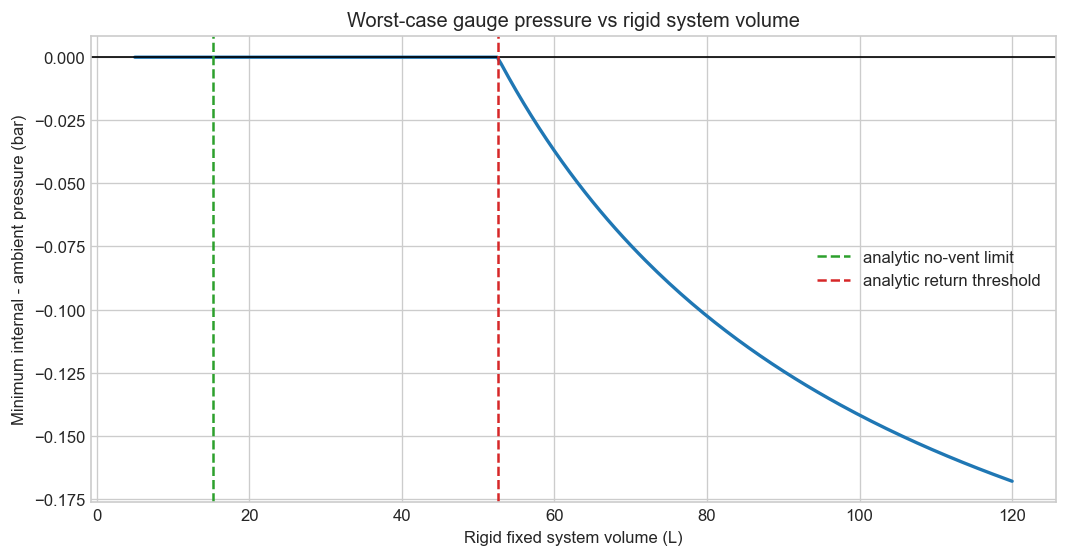

,metric,value_L
0,Simulation: first volume with any venting,15.50
1,Analytic no-vent threshold,15.28
2,Simulation: first volume with negative return ...,53.00
3,Analytic return threshold,52.55


In [11]:
sweep_values = np.linspace(5.0, 120.0, 231)
sweep_records = []

for v_fixed_L in sweep_values:
    _, summary = summarize_case(v_fixed_L=float(v_fixed_L), **DEFAULTS)
    sweep_records.append(summary)

sweep_df = pd.DataFrame(sweep_records)
first_venting_L = sweep_df.loc[sweep_df["total_vented_kg"] > 0.0, "v_fixed_L"].min()
first_negative_L = sweep_df.loc[sweep_df["went_negative"], "v_fixed_L"].min()

fig, ax = plt.subplots(figsize=(9, 4.75))
ax.plot(sweep_df["v_fixed_L"], sweep_df["min_dp_bar"], color="tab:blue", linewidth=2)
ax.axhline(0.0, color="black", linewidth=1.0)
ax.axvline(no_vent_limit_L, color="tab:green", linestyle="--", linewidth=1.5, label="analytic no-vent limit")
ax.axvline(return_limit_ideal_L, color="tab:red", linestyle="--", linewidth=1.5, label="analytic return threshold")
ax.set_title("Worst-case gauge pressure vs rigid system volume")
ax.set_xlabel("Rigid fixed system volume (L)")
ax.set_ylabel("Minimum internal - ambient pressure (bar)")
ax.legend()
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame(
    [
        {"metric": "Simulation: first volume with any venting", "value_L": first_venting_L},
        {"metric": "Analytic no-vent threshold", "value_L": no_vent_limit_L},
        {"metric": "Simulation: first volume with negative return pressure", "value_L": first_negative_L},
        {"metric": "Analytic return threshold", "value_L": return_limit_ideal_L},
    ]
).round(2)
comparison_df


## Optional Cross-Check With MATLAB-Generated Artifacts

- The report handoff treats the MATLAB outputs as the source of truth for the investigation report.
- This cell only inspects what is already on disk so the notebook can cross-reference those generated files without rebuilding the analysis.


In [12]:
artifacts = {
    "threshold_summary_tsv": GENERATED_DIR / "quasistatic_threshold_summary.tsv",
    "case_summary_tsv": GENERATED_DIR / "quasistatic_case_summary.tsv",
    "report_summary_md": GENERATED_DIR / "quasistatic_report_summary.md",
    "min_dp_plot_png": GENERATED_DIR / "quasistatic_min_dp_sweep.png",
}

artifact_df = pd.DataFrame(
    [{"artifact": name, "path": str(path), "exists": path.exists()} for name, path in artifacts.items()]
)
artifact_df


,artifact,path,exists
0,threshold_summary_tsv,D:\matlab-mcp\docs\shipping\generated\quasista...,True
1,case_summary_tsv,D:\matlab-mcp\docs\shipping\generated\quasista...,True
2,report_summary_md,D:\matlab-mcp\docs\shipping\generated\quasista...,True
3,min_dp_plot_png,D:\matlab-mcp\docs\shipping\generated\quasista...,True


In [13]:
threshold_summary_path = artifacts["threshold_summary_tsv"]

if threshold_summary_path.exists():
    pd.read_csv(threshold_summary_path, sep="\t")
else:
    print("MATLAB-generated threshold summary not found; the notebook still runs from the Python model alone.")


## Results

- The analytic thresholds should bracket the transition from no venting to return-leg underpressure for the default bag geometry.
- The `40 L` and `60 L` cases provide a quick sanity check before looking at the full sweep.
- If the measured hardware volume sits near the transition region, re-run the sweep with tighter increments and the actual vent threshold.


## Next Steps

- Replace the `40 L` and `60 L` examples with measured rigid volumes from the actual hardware.
- Repeat the sweep for a nonzero vent threshold such as `2 psig` if that matches the planned hardware.
- Pull the MATLAB-generated tables into the report workflow when the investigation narrative is ready for final numbers.
